# Weather and air quality forecast

## پروژه برسی کیفیت  اب و هوا 


در این پروژه ما سه تا فایل داریم که بهمون اطلاعات کیفیت اب و هوا رو میدن
 
city-info.csv


air_quality_historical.csv-------دیتا ست اصلی



data_dictionary.csv

# پروژه رو به صورت مرحله به مرحله پیش میریم تا بفهمیم در هر بخش چیکارا کردیم

# مرحله 1 — شناخت دیتاست (EDA)

In [1]:
#اضافه کردن کتابخونه هایی که در طول پیش پردازش به کارمون میاد و به  قسمت یادگیری ماشین مربوط نیست و در قسمت خودشون اضافه شدن
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv("air_quality_historical.csv")

#بررسی بازه زمانی (کوچکترین و بزرگترین)
print(df["date"].min())
print(df["date"].max())
# اطلاعات کلی دیتاست
df.info()

# خلاصه آماری
print(df.describe())

# تعداد مقادیر خالی
print(df.isnull().sum())

# تعداد داده های تکراری
print(df.duplicated().sum())

# نمایش چند سطر اول
print(df.head())

# نمایش نام ستون ها
print(df.columns)

# حذف ستون european_aqi
# چون باعث نشت داده میشه
df = df.drop(columns=["european_aqi"])


2022-08-01
2026-02-18
<class 'pandas.DataFrame'>
RangeIndex: 1298 entries, 0 to 1297
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1298 non-null   str    
 1   pm10                   1295 non-null   float64
 2   pm2_5                  1295 non-null   float64
 3   carbon_monoxide        1295 non-null   float64
 4   nitrogen_dioxide       1295 non-null   float64
 5   sulphur_dioxide        1295 non-null   float64
 6   ozone                  1295 non-null   float64
 7   aerosol_optical_depth  1295 non-null   float64
 8   dust                   1295 non-null   float64
 9   uv_index               1295 non-null   float64
 10  us_aqi                 1294 non-null   float64
 11  european_aqi           1294 non-null   float64
dtypes: float64(11), str(1)
memory usage: 121.8 KB
              pm10        pm2_5  carbon_monoxide  nitrogen_dioxide  \
count  1295.000000  1295.000000  

# مرحله ۲ - Data Cleaning (پیش‌پردازش داده‌ها)

بعد از انجام مرحله 1 میریم سراغ مرحله 2 جایی که بعد از شناخت اولیه دیتا ست میریم که دیتا ست رو پاک سازی کنیم

در این مرحله قرار است:

مقادیر خالی را بررسی کنیم.

داده‌های تکراری را حذف کنیم.

داده های پرت را شناسایی میکنیم

## شناسایی مقادیر خالی ----------------------------------------------------------------------

In [3]:
# تعداد مقادیر خالی هر ستون
print(df.isnull().sum())

date                     0
pm10                     3
pm2_5                    3
carbon_monoxide          3
nitrogen_dioxide         3
sulphur_dioxide          3
ozone                    3
aerosol_optical_depth    3
dust                     3
uv_index                 3
us_aqi                   4
dtype: int64


# برسی و حذف مقادیر تکراری-------------------------------------------

بعد از پر کردن مقادیر خالی باید مقادیر پر شده را چک کنیم تا  تکراری نباشن

In [4]:
# تعداد ردیف های تکراری
print(df.duplicated().sum())

0


بعد از برسی اقدام به حذف میکنیم در صورتی که وجود داشت

In [5]:
# حذف ردیف های تکراری
df = df.drop_duplicates()

و در اخر هم یه برسی میکنیم که ایا چیزی حذف شده یا نه

In [6]:
# بررسی تعداد داده ها بعد از حذف تکراری ها
print(df.shape)

(1298, 11)


## بررسی Outlier--------------------------------------------------------------

برسی داده ها با نمودار ها

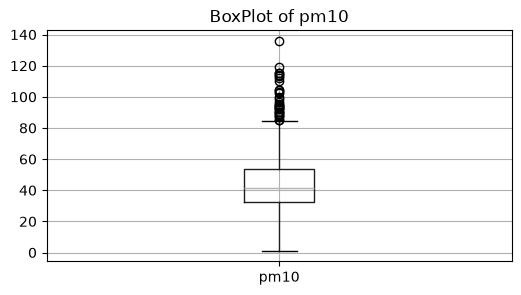

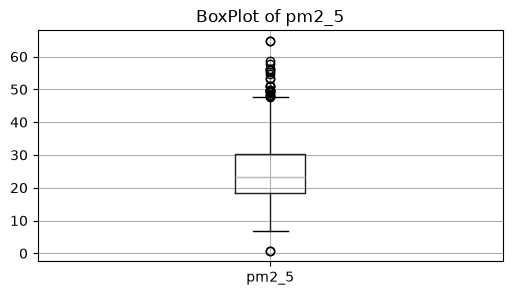

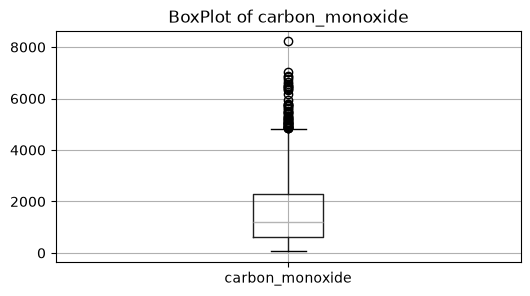

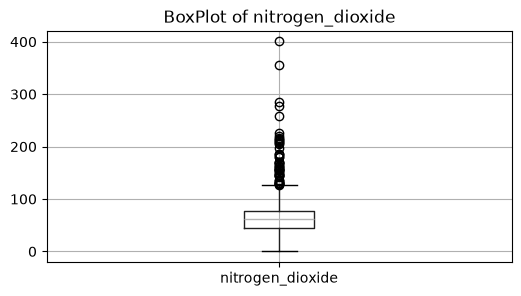

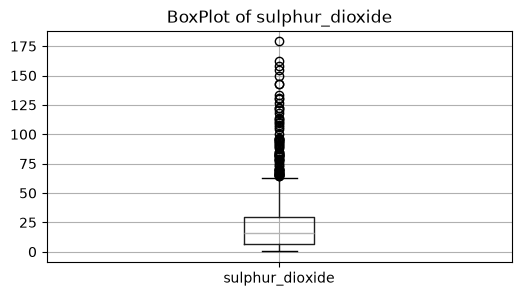

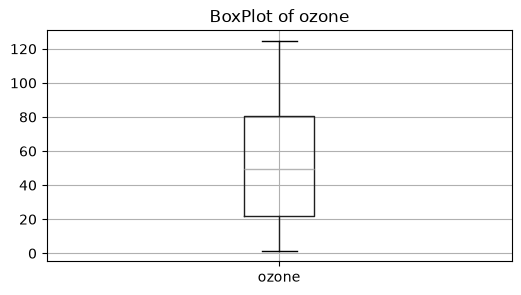

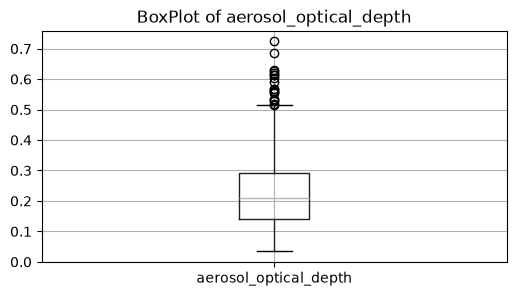

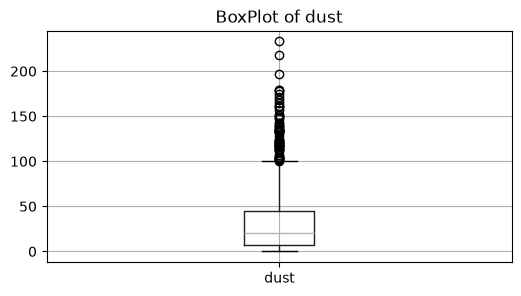

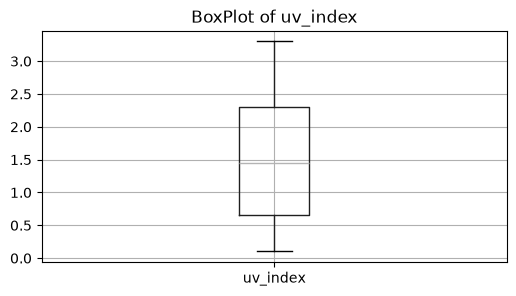

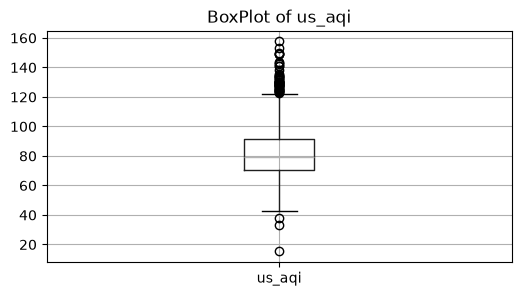

In [7]:
# انتخاب ستون های عددی
numeric_df = df.select_dtypes(include="number")

# رسم BoxPlot هر ستون به صورت جداگانه
for column in numeric_df.columns:

    plt.figure(figsize=(6,3))

    df.boxplot(column=column)

    plt.title(f"BoxPlot of {column}")

    plt.show()

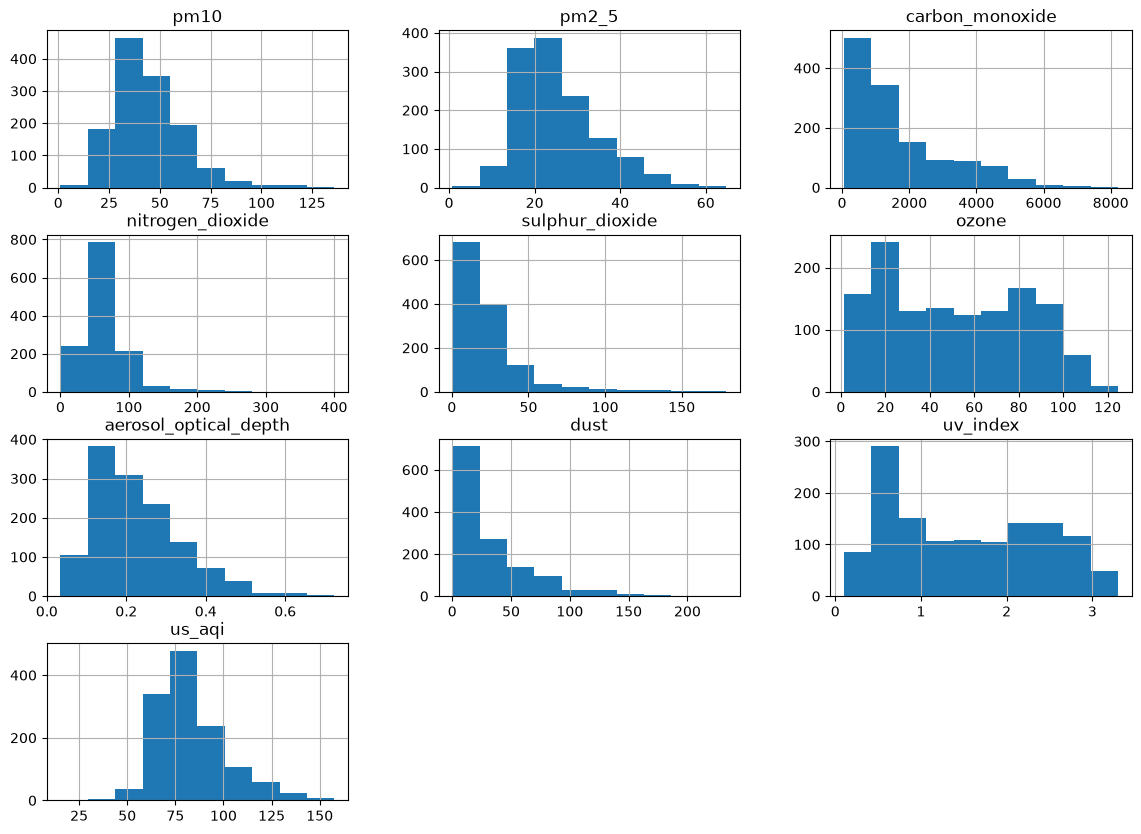

In [8]:
# رسم Histogram برای تمام ستون های عددی
numeric_df.hist(figsize=(14,10))

plt.show()

اول ستون های عددی رو انتخاب میکنیم که کار روی اونا انجام بشه 

محاسبه IQR 

و مرز بالا و پایین

In [9]:
# محاسبه چارک ها
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

# محاسبه IQR
IQR = Q3 - Q1
# محاسبه حد پایین و بالا
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

In [10]:
# نمایش حد بالا و پایین هر ستون
bounds = pd.DataFrame({

    "Lower Bound": lower_bound,

    "Upper Bound": upper_bound

})

print(bounds)

                       Lower Bound  Upper Bound
pm10                    -30.520833   116.289583
pm2_5                   -16.516667    65.237500
carbon_monoxide       -4445.812500  7359.687500
nitrogen_dioxide        -52.693750   174.864583
sulphur_dioxide         -60.989583    97.662500
ozone                  -153.833333   255.958333
aerosol_optical_depth    -0.308958     0.741042
dust                   -105.395833   156.958333
uv_index                 -4.265625     7.233333
us_aqi                    8.427083   153.677083


In [11]:
# شمارش داده های پرت
outliers_count = ((numeric_df < lower_bound) | (numeric_df > upper_bound)).sum()

print("تعداد Outlier هر ستون:")
# نمایش تعداد داده های پرت هر ستون
for column in outliers_count.index:

    print(f"{column} : {outliers_count[column]}")



تعداد Outlier هر ستون:
pm10 : 2
pm2_5 : 0
carbon_monoxide : 1
nitrogen_dioxide : 20
sulphur_dioxide : 24
ozone : 0
aerosol_optical_depth : 0
dust : 13
uv_index : 0
us_aqi : 1


داده‌های پرت با روش 

IQR

 شناسایی شدند. با توجه به اینکه این دیتاست مربوط به کیفیت هواست، مقادیر بزرگ لزوماً خطا نیستند و ممکن است ناشی از آلودگی شدید یا شرایط خاص جوی باشند. بنابراین در این مرحله داده‌ها حذف نشدند و تنها شناسایی و بررسی شدند.

و در اخر مرحله 2 یه برسی کلی به دیتا ست میندازیم ببینیم چطور شد  

In [12]:
# نمایش اطلاعات کلی دیتاست
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1298 entries, 0 to 1297
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1298 non-null   str    
 1   pm10                   1295 non-null   float64
 2   pm2_5                  1295 non-null   float64
 3   carbon_monoxide        1295 non-null   float64
 4   nitrogen_dioxide       1295 non-null   float64
 5   sulphur_dioxide        1295 non-null   float64
 6   ozone                  1295 non-null   float64
 7   aerosol_optical_depth  1295 non-null   float64
 8   dust                   1295 non-null   float64
 9   uv_index               1295 non-null   float64
 10  us_aqi                 1294 non-null   float64
dtypes: float64(10), str(1)
memory usage: 111.7 KB


In [13]:
print(df.columns)

Index(['date', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide',
       'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index',
       'us_aqi'],
      dtype='str')


# مرحله 3 : Feature Engineering (ساخت ویژگی‌های جدید)

### تبدیل تاریخ

In [14]:
# تبدیل ستون تاریخ به نوع datetime
df["date"] = pd.to_datetime(df["date"])

### مرتب کردن داده‌ها(درصورت نیاز)

چون داده های بر اساس تاریخ هستن نیاز داریم مرتبشون هم بکنیم که کارمون هم اصولی و تمیز تر در بیاد

In [15]:
# مرتب کردن داده ها بر اساس تاریخ
df = df.sort_values("date")
# مرتب کردن شماره سطرها
df = df.reset_index(drop=True)

استخراج سال ,ماه , روز, روز هفته , شماره هفته سال,

In [16]:
# استخراج سال
df["year"] = df["date"].dt.year
# استخراج ماه
df["month"] = df["date"].dt.month
# استخراج روز ماه
df["day"] = df["date"].dt.day
# استخراج روز هفته
df["day_of_week"] = df["date"].dt.dayofweek
# استخراج شماره هفته سال
df["week_of_year"] = df["date"].dt.isocalendar().week

حالا میاییم بر اساس تاریخ هایی که داریم فصل  رو هم استخراج میکنیم 

In [17]:
# تبدیل ماه به فصل
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


df["season"] = df["month"].apply(get_season)

نتیجشو هم میبینیم 

In [18]:
# نمایش چند سطر از ویژگی های جدید
print(
    df[
        [
            "date",
            "year",
            "month",
            "day",
            "day_of_week",
            "week_of_year",
            "season"
        ]
    ].head(10)
)

        date  year  month  day  day_of_week  week_of_year  season
0 2022-08-01  2022      8    1            0            31  Summer
1 2022-08-02  2022      8    2            1            31  Summer
2 2022-08-03  2022      8    3            2            31  Summer
3 2022-08-04  2022      8    4            3            31  Summer
4 2022-08-05  2022      8    5            4            31  Summer
5 2022-08-06  2022      8    6            5            31  Summer
6 2022-08-07  2022      8    7            6            31  Summer
7 2022-08-08  2022      8    8            0            32  Summer
8 2022-08-09  2022      8    9            1            32  Summer
9 2022-08-10  2022      8   10            2            32  Summer


در این مرحله اومدیم با داده هایی که داشتیم ویژگی های جدید ساختیم

# مرحله ۴ : بررسی توزیع داده‌ها (Distribution Analysis)

یعنی باید ببینیم:

داده‌ها نرمال هستند یا خیر؟

چولگی (Skewness) دارند؟

آیا لازم است قبل از آموزش مدل داده‌ها را تبدیل کنیم؟

### برسی نرمال بودن
برای اینکه بفهمیم داده های نرمال هستن میتونیم از رسم هیستو گرام اون به صورت چشمی ببینیم

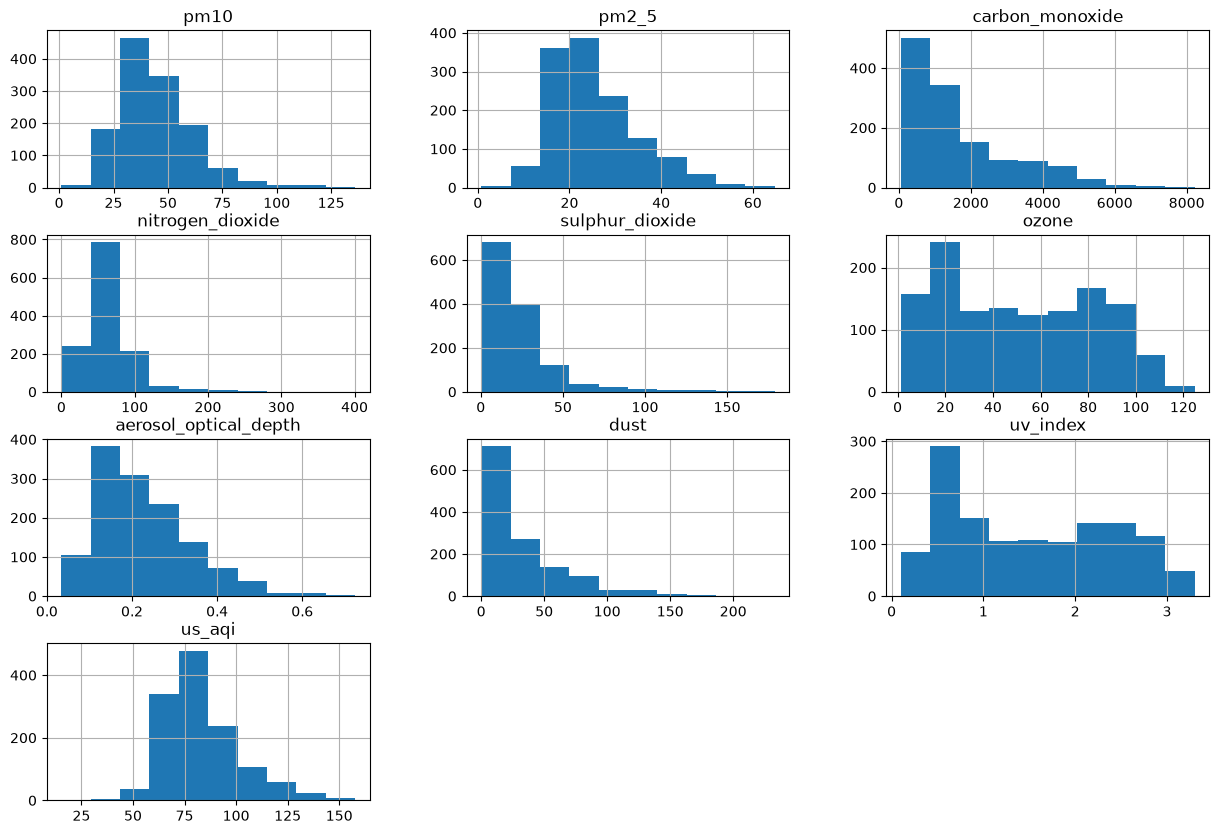

In [19]:

numeric_df.hist(figsize=(15,10))


plt.show()

###  محاسبه Skewness

حالا مقدار چولگی را حساب می‌کنیم.

In [20]:
# محاسبه چولگی ستون های عددی
skewness = numeric_df.skew()

print(skewness.sort_values(ascending=False))

nitrogen_dioxide         3.012291
sulphur_dioxide          2.614981
dust                     1.818384
carbon_monoxide          1.348096
pm10                     1.128935
us_aqi                   0.973236
aerosol_optical_depth    0.949671
pm2_5                    0.892617
uv_index                 0.221881
ozone                    0.186830
dtype: float64


|  مقدار Skewness | معنی             |
| --------------: | ---------------- |
| بین -0.5 تا 0.5 | تقریباً نرمال    |
|    بین 0.5 تا 1 | کمی چوله         |
|      بیشتر از 1 | چولگی زیاد       |
|      کمتر از -1 | چولگی شدید به چپ |


تحلیل توزیع داده‌ها

با بررسی مقدار 

Skewness

 مشاهده شد که برخی ویژگی‌ها مانند 

 sulphur_dioxide و nitrogen_dioxide

 دارای چولگی مثبت هستند. این موضوع به دلیل وقوع روزهای با آلودگی شدید طبیعی است و لزوماً نشان‌دهنده خطای داده نیست. در این مرحله هیچ تبدیلی روی داده‌ها اعمال نشد و وضعیت چولگی برای مراحل بعدی مدل‌سازی ثبت گردید.

برای دیدین این چولگی ها میتونیم به جای هیستوگرام از 

 KDE Plot  برای نمایش هم استفاده کنیم

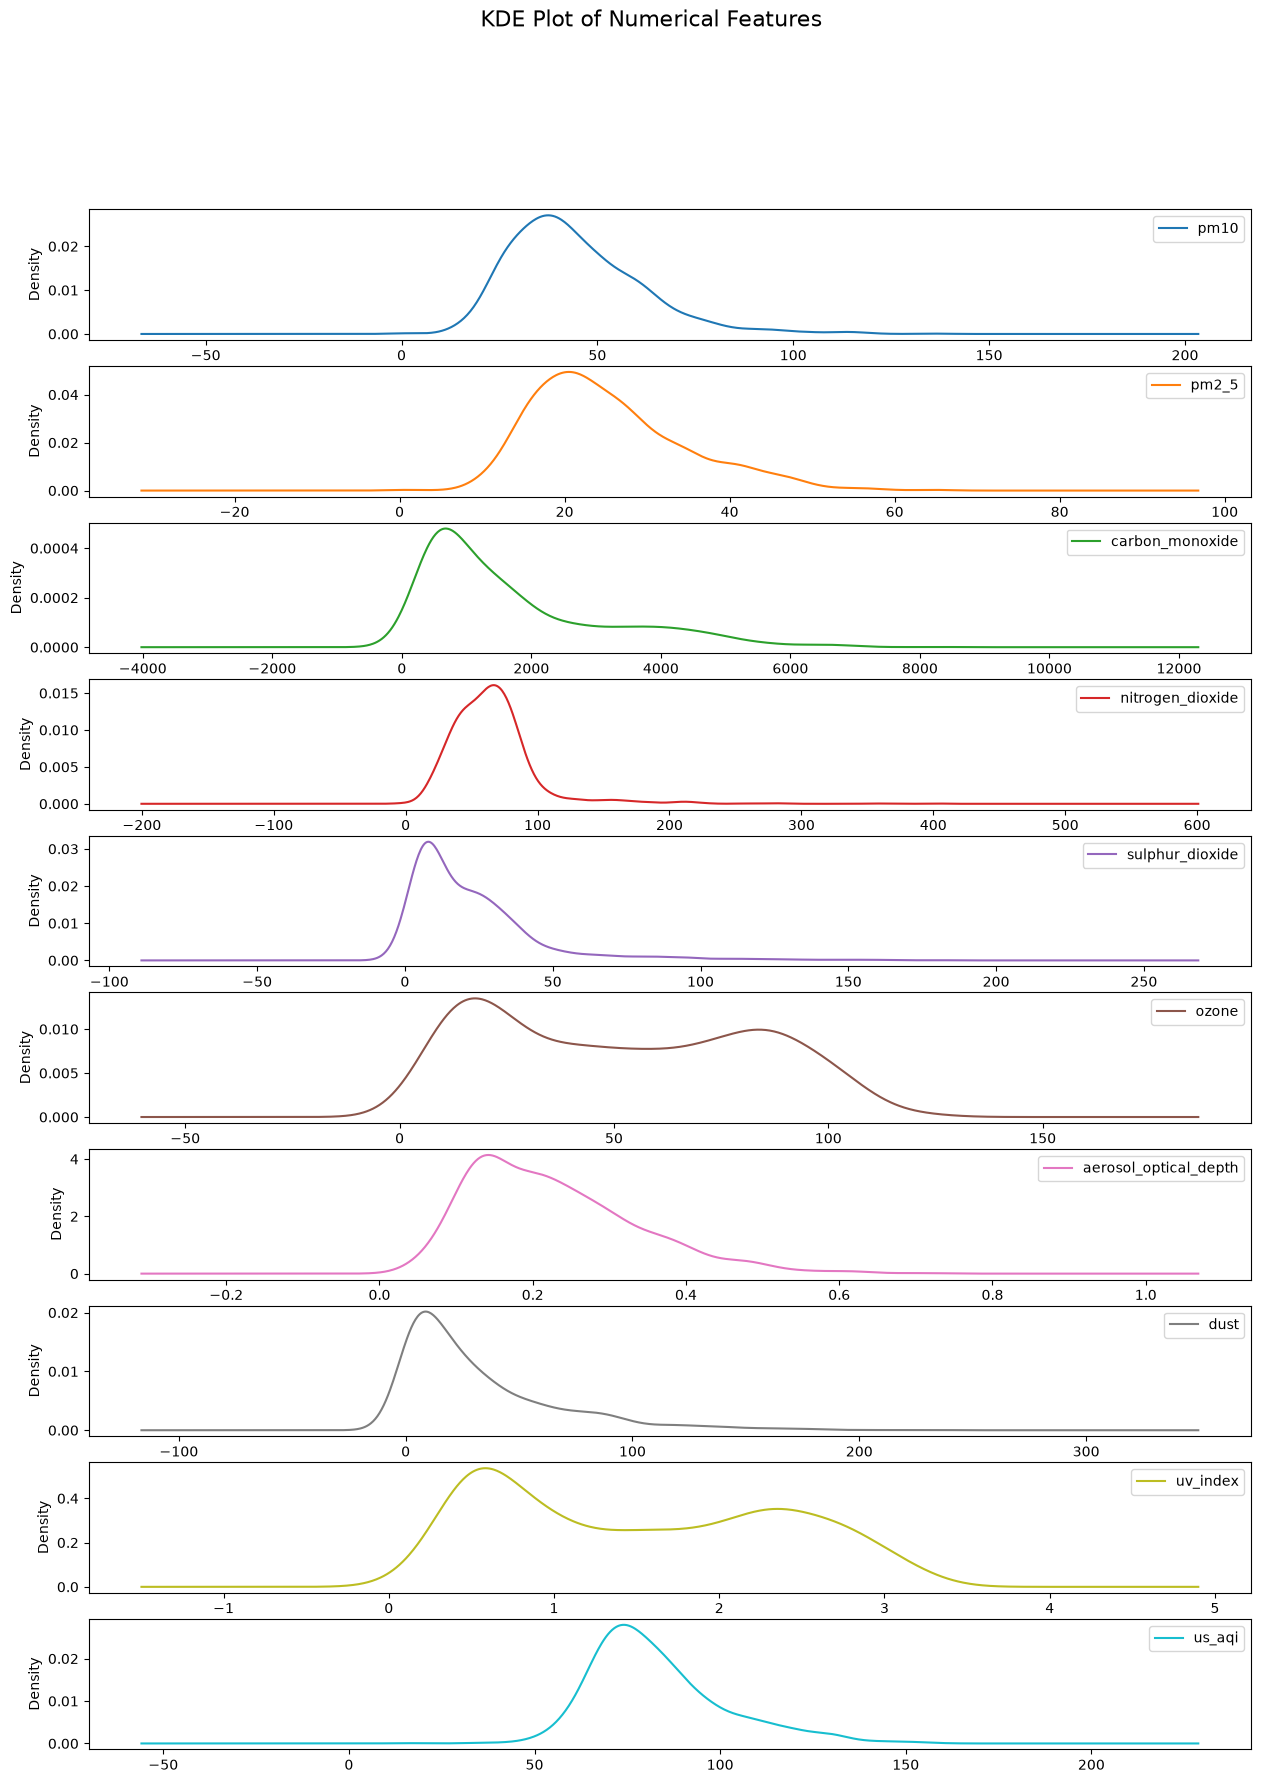

In [21]:

# رسم KDE برای همه ستون ها
numeric_df.plot(
    kind="density",
    subplots=True,
    figsize=(15, 20),
    sharex=False
   
)

plt.suptitle("KDE Plot of Numerical Features", fontsize=16)
plt.show()

# مرحله 5 : انتخاب ویژگی‌ها (Feature Selection)
 

 در این مرحله باید دنبال پیدا کردن ویژگی‌های مؤثر بر تارگت 
 
 (Correlation & Mutual Information)

یعنی باید بفهمیم:

کدام ستون‌ها بیشترین تأثیر را روی 

Target 

دارند؟


In [22]:
# محاسبه همبستگی
correlation = numeric_df.corr()

print(correlation)

                           pm10     pm2_5  carbon_monoxide  nitrogen_dioxide  \
pm10                   1.000000  0.599791         0.064105          0.166071   
pm2_5                  0.599791  1.000000         0.632930          0.626501   
carbon_monoxide        0.064105  0.632930         1.000000          0.365458   
nitrogen_dioxide       0.166071  0.626501         0.365458          1.000000   
sulphur_dioxide        0.087312  0.487908         0.186770          0.843098   
ozone                 -0.055884 -0.617765        -0.615333         -0.665874   
aerosol_optical_depth  0.501893  0.174819        -0.239274         -0.027070   
dust                   0.694235 -0.080751        -0.296263         -0.432650   
uv_index              -0.112589 -0.616446        -0.568263         -0.605839   
us_aqi                 0.447766  0.832435         0.537010          0.525410   

                       sulphur_dioxide     ozone  aerosol_optical_depth  \
pm10                          0.087312 -0.05

به کد خروجی بالا نگاه کنید 

فکر کنم چیزی متوجه نشید ازش ولی میتونی با رسم یک نمودار کارو راحت کنیم

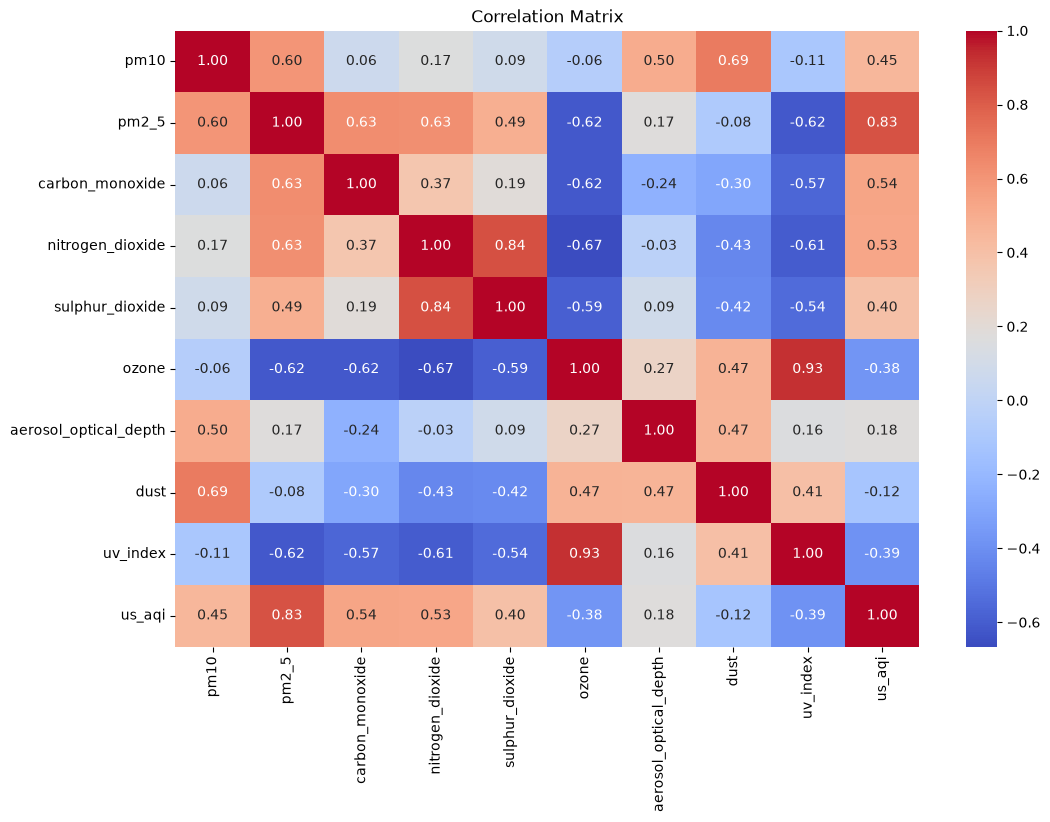

In [23]:
import seaborn as sns
# رسم Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")

plt.show()

در این نمودار اگر عدد نزدیک 1 باشد 
یعنی دو ویژگی رابطه مستقیم و قوی دارند

اگر -1 باشد یعنی رابطه معکوس قوی دارد

اگر 0 باشد یعنی هیچ ارتباطی ندارن

## مرتب کردن ویژگی ها نسبت به Target



معمولا در در همچین دیتاست هایی شاخص کیفیت هوا رو در نظر میگیرن که در این پروژه 

us_aqi 

است

In [24]:
# مرتب کردن ویژگی ها نسبت به Target
target_corr = correlation["us_aqi"].sort_values(ascending=False)

print(target_corr)

us_aqi                   1.000000
pm2_5                    0.832435
carbon_monoxide          0.537010
nitrogen_dioxide         0.525410
pm10                     0.447766
sulphur_dioxide          0.395108
aerosol_optical_depth    0.177786
dust                    -0.122776
ozone                   -0.376373
uv_index                -0.386691
Name: us_aqi, dtype: float64


#### الان دقیقاً می‌فهمیم چه ستون‌هایی مهم‌تر هستند.

### Mutual Information

Correlation 

فقط رابطه خطی را پیدا می‌کند.

ولی 

Mutual Information 

حتی رابطه‌های غیرخطی را هم پیدا می‌کند.

In [25]:
from sklearn.feature_selection import mutual_info_regression

# یک کپی برای تحلیل می‌سازیم
df_mi = df.copy()

# فقط برای محاسبه MI مقادیر خالی را پر می‌کنیم
df_mi = df_mi.fillna(df_mi.median(numeric_only=True))

# ویژگی‌ها
X_mi = df_mi.drop(columns=["date", "us_aqi"])

# تارگت
y_mi = df_mi["us_aqi"]

# تبدیل ستون‌های متنی به عددی
X_mi = pd.get_dummies(X_mi, drop_first=True)

# محاسبه اهمیت ویژگی‌ها
mi = mutual_info_regression(X_mi, y_mi)

# ساخت جدول نتایج
mi_df = pd.DataFrame({
    "Feature": X_mi.columns,
    "Importance": mi
})

# مرتب‌سازی
mi_df = mi_df.sort_values(by="Importance", ascending=False)

print(mi_df)

                  Feature  Importance
1                   pm2_5    0.588238
5                   ozone    0.237425
13           week_of_year    0.227973
2         carbon_monoxide    0.215220
10                  month    0.202958
3        nitrogen_dioxide    0.189479
0                    pm10    0.153791
4         sulphur_dioxide    0.147312
8                uv_index    0.145165
7                    dust    0.076760
16          season_Winter    0.047138
15          season_Summer    0.043510
14          season_Spring    0.036818
6   aerosol_optical_depth    0.035994
9                    year    0.032225
11                    day    0.001424
12            day_of_week    0.001421


رسم نمودار برای مقادیری که بدست اوردیم

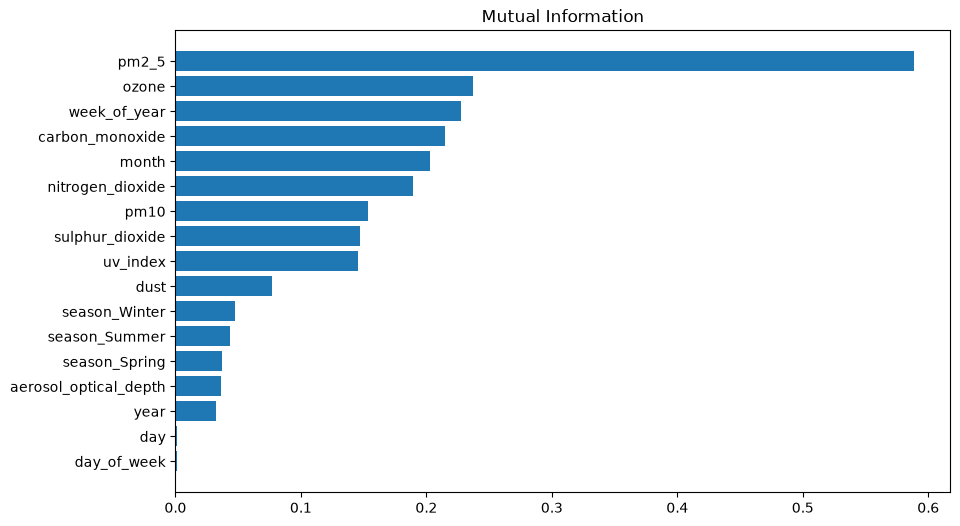

In [26]:
plt.figure(figsize=(10,6))

plt.barh(
    mi_df["Feature"],
    mi_df["Importance"]
)

plt.title("Mutual Information")

plt.gca().invert_yaxis()

plt.show()

در این مرحله ارتباط ویژگی‌ها با متغیر هدف بررسی شد.

ابتدا با استفاده از 

Correlation

 رابطه خطی بین ویژگی‌ها و شاخص کیفیت هوا محاسبه گردید.


سپس با استفاده از 

Mutual Information

 میزان اهمیت هر ویژگی حتی در روابط غیرخطی نیز اندازه‌گیری شد.


نتایج نشان داد که آلاینده‌هایی مانند 

PM2.5 و PM10 

بیشترین تأثیر را بر شاخص 
کیفیت هوا دارند.

# مرحله 6 : تقسیم داده‌ها (Train/Test Split)

اصلاً چرا داده‌ها را تقسیم می‌کنیم؟

فرض کن 1298 رکورد داریم.

اگر همه را به مدل بدهیم، دیگر نمی‌توانیم بفهمیم مدل واقعاً چیزی یاد گرفته یا فقط داده‌ها را حفظ کرده است.

### در اولین گام تارگت رو تعیین میکنیم

In [27]:
# متغیر هدف
# حذف ردیف‌هایی که تارگت خالی دارند
df = df.dropna(subset=["us_aqi"]).copy()
# ویژگی‌ها
X = df.drop(columns=["date", "us_aqi"])

# تارگت
y = df["us_aqi"]

### ویژگی‌ها

یعنی بقیه ستون های میشن  ویژگی

In [28]:
# ویژگی ها
X = df.drop(columns=["us_aqi"])

چرا جداش کردیم چون اگر مدل بفهمد جواب ما چی هست دیگه یاد نمیگیره خودش جواب بده 

میره جواب اماده مارو که کیفیت هوا است رو میزاره کف دست ما پس جداش میکنیم از بقیه ستون ها تا با یادگرفتن بعدا خودش جواب بو حدس بزنه

### حذف تاریخ

مدل‌ها تاریخ را متوجه نمی‌شوند.

In [29]:
# حذف ستون تاریخ
X = X.drop(columns=["date"])

### تبدیل ستون‌های متنی

اگر ستون متنی داشته باشیم:

In [30]:
# تبدیل داده های متنی
X = pd.get_dummies(X, drop_first=True)

تقسیم داده

In [31]:
from sklearn.model_selection import train_test_split

# تقسیم داده ها
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    #به خاطر وحود ارتباط بین روز های در حالت غیر فعال است
    shuffle=False
)

# چرا shuffle=True نیست؟
# چون اگر فعال باشد داده  ممکنه به صورت به هم ریخته تقسیم بشن و دیگه اون ارتباطه  بین روز ها نباشه

بررسی اندازه داده‌ها

In [32]:
print("X_train :", X_train.shape)

print("X_test :", X_test.shape)

print("y_train :", y_train.shape)

print("y_test :", y_test.shape)

X_train : (1035, 17)
X_test : (259, 17)
y_train : (1035,)
y_test : (259,)


# پر کردن مقادیر خالی

بعد از برسی مقادیر خالی باید اون مقادیر رو پر کنیم 
قبلش میاییم ستون های عددی رو جدا میکنیم چون 

knn

فقط روی داده های عددی کار میکند


In [33]:
# انتخاب ستون های عددی
numeric_columns = df.select_dtypes(include=["number"]).columns

ساخت KNNImputer

In [34]:
# ساخت شیء KNN
imputer = KNNImputer(n_neighbors=5)

توضیح

n_neighbors=5

یعنی برای پر کردن هر مقدار خالی، ۵ نمونه‌ی مشابه را پیدا کند و از آن‌ها میانگین بگیرد.

In [35]:


# یادگیری فقط روی Train
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# اعمال روی Test
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index)

الگوی داده‌ها را یاد می‌گیرد (fit)

مقادیر خالی را پر می‌کند (transform)

In [36]:
# بررسی اینکه همه مقادیر خالی پر شده باشند
print(X_test.isnull().sum())
()
print(X_train.isnull().sum())


pm10                     0
pm2_5                    0
carbon_monoxide          0
nitrogen_dioxide         0
sulphur_dioxide          0
ozone                    0
aerosol_optical_depth    0
dust                     0
uv_index                 0
year                     0
month                    0
day                      0
day_of_week              0
week_of_year             0
season_Spring            0
season_Summer            0
season_Winter            0
dtype: int64
pm10                     0
pm2_5                    0
carbon_monoxide          0
nitrogen_dioxide         0
sulphur_dioxide          0
ozone                    0
aerosol_optical_depth    0
dust                     0
uv_index                 0
year                     0
month                    0
day                      0
day_of_week              0
week_of_year             0
season_Spring            0
season_Summer            0
season_Winter            0
dtype: int64


# StandardScaler

In [37]:
from sklearn.preprocessing import StandardScaler

# ساخت شیء Scaler
scaler = StandardScaler()

# یادگیری از داده های آموزش
X_train_scaled = scaler.fit_transform(X_train)

# اعمال همان مقیاس روی داده های تست
X_test_scaled = scaler.transform(X_test)

دلیل استفاده از standardscaler:

StandardScaler 

باعث می‌شود همه ویژگی‌ها در یک مقیاس قرار بگیرند تا هیچ ستونی فقط به خاطر بزرگ‌تر بودن اعدادش، روی مدل تأثیر بیشتری نداشته باشد

# Machine Learning

### در این مرحله وارد بخش عملی کار میشیم جایی که باید الگوریتم ها رو پیاده سازی کنیم

 در مرحله اول الگورتیم 

## Linear Regression

  رو پیاده سازی میکنیم 


In [38]:
print(df["us_aqi"].isnull().sum())

0


قبل از اموزش حتما باید مقادیر  تارگتی که داریم پر باشن  وگرنه مدل در همون اول ارور میده که مقدار خالی داری
ما حذف میکنیم تا پیش بینی مدل  مشکلی براش پیش نیاد

In [39]:
print("NaN در y :", y.isnull().sum())

print("NaN در y_train :", y_train.isnull().sum())

print("NaN در y_test :", y_test.isnull().sum())

print("Shape y_train :", y_train.shape)

print("Shape y_test :", y_test.shape)

NaN در y : 0
NaN در y_train : 0
NaN در y_test : 0
Shape y_train : (1035,)
Shape y_test : (259,)


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ساخت مدل
model = LinearRegression()

# آموزش مدل
model.fit(X_train_scaled, y_train)
# پیش‌بینی روی داده‌های تست
y_pred = model.predict(X_test_scaled)
print(y_pred)
# محاسبه معیارهای ارزیابی
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.3f}")


[ 68.34529915  66.52217619  81.68971071  94.20496587  98.28067288
  98.20998933  94.75566902  90.50232289  94.48354177  84.03672378
  79.92478634  74.86157505  73.04485832  75.80997234  68.85463625
  71.00213681  79.18468818  81.25819457  78.32183555  86.20904733
  73.85825219  86.17366734  88.11204914  82.14444203  79.62756094
  90.2506781   86.63207573  85.56162011  89.79423452  82.64659354
  78.97647901  76.89129164  67.66598714  68.0994046   76.03548314
  93.916532    97.41760852  98.83310131 121.66662678  88.73727825
  77.94778415  74.51831022  73.96929003  71.27668603  68.47784083
  73.65579823  79.7707758   76.29045592  71.22471599  74.90344908
  75.78019125  72.22812083  82.08472378  90.29626367 101.4225568
 107.97756544 108.57625058  74.79275165  66.92381544  72.98096347
  78.77238179  80.42940633  81.92671084  91.87649199  85.57909838
  78.56857273  70.76915111  72.28386454  79.54478978  78.75975753
  79.91631878  80.40131427  83.74468371  91.54127174  92.66710463
  93.947685

قبل از اینکه بریم سراغ بقیه الگوریتم ها یه برسی میکنیم که مدل 

overfitting 

میکنه یا نه

In [41]:
# پیش بینی روی داده های آموزش
y_train_pred = model.predict(X_train_scaled)

# پیش بینی روی داده های تست
y_test_pred = model.predict(X_test_scaled)

محاسبه خطا داد ها

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ارزیابی داده های آموزش 
lr_train_mae = mean_absolute_error(y_train, y_train_pred)
lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
lr_train_r2 = r2_score(y_train, y_train_pred)

# ارزیابی داده های تست
lr_mae = mean_absolute_error(y_test, y_test_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
lr_r2 = r2_score(y_test, y_test_pred)

نمایش نتایج

In [43]:
print("===== Train =====")
print(f"MAE : {lr_train_mae:.2f}")
print(f"RMSE: {lr_train_rmse:.2f}")
print(f"R²  : {lr_train_r2:.3f}")

print("\n===== Test =====")
print(f"MAE : {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R²  : {lr_r2:.3f}")

===== Train =====
MAE : 6.31
RMSE: 8.35
R²  : 0.784

===== Test =====
MAE : 6.98
RMSE: 8.84
R²  : 0.743


مدل 

Linear Regression

عملکرد قابل قبولی داشت و با 

R² 

برابر 0.743 روی داده‌های تست توانست بخش قابل توجهی از تغییرات کیفیت هوا را 
مدل‌سازی کند. اختلاف کم بین معیارهای آموزش و آزمون نشان می‌دهد که مدل دچار

 Overfitting 

نشده است.

## مدل دوم: KNN Regressor

In [44]:
from sklearn.neighbors import KNeighborsRegressor

# ساخت مدل KNN
knn = KNeighborsRegressor(n_neighbors=5)

# آموزش مدل
knn.fit(X_train_scaled, y_train)

# پیش بینی روی Train
y_train_pred = knn.predict(X_train_scaled)

# پیش بینی روی Test
y_test_pred = knn.predict(X_test_scaled)

# Train 
knn_train_mae = mean_absolute_error(y_train, y_train_pred)
knn_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
knn_train_r2 = r2_score(y_train, y_train_pred)

# Test
knn_mae = mean_absolute_error(y_test, y_test_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
knn_r2 = r2_score(y_test, y_test_pred)

#نمایش نتیجه
print("===== KNN Train =====")
print(f"MAE : {knn_train_mae:.2f}")
print(f"RMSE: {knn_train_rmse:.2f}")
print(f"R²  : {knn_train_r2:.3f}")

print("\n===== KNN Test =====")
print(f"MAE : {knn_mae:.2f}")
print(f"RMSE: {knn_rmse:.2f}")
print(f"R²  : {knn_r2:.3f}")

===== KNN Train =====
MAE : 5.98
RMSE: 7.85
R²  : 0.809

===== KNN Test =====
MAE : 9.47
RMSE: 11.95
R²  : 0.531


## مدل سوم : Decision Tree Regressor

In [45]:
from sklearn.tree import DecisionTreeRegressor

# ساخت مدل
tree = DecisionTreeRegressor(
    max_depth=5,        # حداکثر عمق درخت| یعنی بیشتر از 5 مرحله رشد نکنه 
    random_state=42     # ثابت بودن نتایج
)
# آموزش مدل
tree.fit(X_train_scaled, y_train)
# پیش بینی روی داده های آموزش
y_train_pred = tree.predict(X_train_scaled)

# پیش بینی روی داده های تست
y_test_pred = tree.predict(X_test_scaled)

محاسبه معیارها

In [46]:
# Train 
tree_train_mae = mean_absolute_error(y_train, y_train_pred)
tree_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
tree_train_r2 = r2_score(y_train, y_train_pred)

# Test
tree_mae = mean_absolute_error(y_test, y_test_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
tree_r2 = r2_score(y_test, y_test_pred)

نمایش نتایج

In [47]:
print("===== Decision Tree Train =====")
print(f"MAE : {tree_train_mae:.2f}")
print(f"RMSE: {tree_train_rmse:.2f}")
print(f"R²  : {tree_train_r2:.3f}")

print("\n===== Decision Tree Test =====")
print(f"MAE : {tree_mae:.2f}")
print(f"RMSE: {tree_rmse:.2f}")
print(f"R²  : {tree_r2:.3f}")

===== Decision Tree Train =====
MAE : 5.85
RMSE: 7.53
R²  : 0.824

===== Decision Tree Test =====
MAE : 7.75
RMSE: 9.88
R²  : 0.680


## مدل چهارم : Random Forest

In [48]:
from sklearn.ensemble import RandomForestRegressor

# ساخت مدل Random Forest
forest = RandomForestRegressor(
    n_estimators=100,   # تعداد درخت‌ها
    max_depth=8,        #(برای جلوگیری از overfittingو حفظ داده ) حداکثر عمق هر درخت
    random_state=42,
    n_jobs=-1           # استفاده از تمام هسته‌های CPU
)

# آموزش مدل
forest.fit(X_train_scaled, y_train)
# پیش بینی روی Train
y_train_pred = forest.predict(X_train_scaled)

# پیش بینی روی Test
y_test_pred = forest.predict(X_test_scaled)

# Train 
forest_train_mae = mean_absolute_error(y_train, y_train_pred)
forest_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
forest_train_r2 = r2_score(y_train, y_train_pred)

# Test
forest_mae = mean_absolute_error(y_test, y_test_pred)
forest_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
forest_r2 = r2_score(y_test, y_test_pred)

نمایش نتایج

In [49]:
print("===== Random Forest Train =====")
print(f"MAE : {forest_train_mae:.2f}")
print(f"RMSE: {forest_train_rmse:.2f}")
print(f"R²  : {forest_train_r2:.3f}")

print("\n===== Random Forest Test =====")
print(f"MAE : {forest_mae:.2f}")
print(f"RMSE: {forest_rmse:.2f}")
print(f"R²  : {forest_r2:.3f}")

===== Random Forest Train =====
MAE : 4.01
RMSE: 5.08
R²  : 0.920

===== Random Forest Test =====
MAE : 6.90
RMSE: 8.82
R²  : 0.745


# Ridge Regression

In [50]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ساخت مدل
ridge = Ridge(alpha=1.0)

# آموزش مدل
ridge.fit(X_train_scaled, y_train)

# پیش بینی
y_train_pred = ridge.predict(X_train_scaled)
y_test_pred = ridge.predict(X_test_scaled)

# محاسبه معیارها 
ridge_train_mae = mean_absolute_error(y_train, y_train_pred)
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
ridge_train_r2 = r2_score(y_train, y_train_pred)

ridge_mae = mean_absolute_error(y_test, y_test_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
ridge_r2 = r2_score(y_test, y_test_pred)

print("===== Ridge Train =====")
print(f"MAE : {ridge_train_mae:.2f}")
print(f"RMSE: {ridge_train_rmse:.2f}")
print(f"R²  : {ridge_train_r2:.3f}")

print("\n===== Ridge Test =====")
print(f"MAE : {ridge_mae:.2f}")
print(f"RMSE: {ridge_rmse:.2f}")
print(f"R²  : {ridge_r2:.3f}")

===== Ridge Train =====
MAE : 6.31
RMSE: 8.35
R²  : 0.784

===== Ridge Test =====
MAE : 6.99
RMSE: 8.86
R²  : 0.742


# Lasso Regression

In [51]:
from sklearn.linear_model import Lasso

# ساخت مدل
lasso = Lasso(alpha=0.1)

# آموزش
lasso.fit(X_train_scaled, y_train)

# پیش بینی
y_train_pred = lasso.predict(X_train_scaled)
y_test_pred = lasso.predict(X_test_scaled)

# ارزیابی 
lasso_train_mae = mean_absolute_error(y_train, y_train_pred)
lasso_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
lasso_train_r2 = r2_score(y_train, y_train_pred)

lasso_mae = mean_absolute_error(y_test, y_test_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
lasso_r2 = r2_score(y_test, y_test_pred)

print("===== Lasso Train =====")
print(f"MAE : {lasso_train_mae:.2f}")
print(f"RMSE: {lasso_train_rmse:.2f}")
print(f"R²  : {lasso_train_r2:.3f}")

print("\n===== Lasso Test =====")
print(f"MAE : {lasso_mae:.2f}")
print(f"RMSE: {lasso_rmse:.2f}")
print(f"R²  : {lasso_r2:.3f}")

===== Lasso Train =====
MAE : 6.36
RMSE: 8.39
R²  : 0.782

===== Lasso Test =====
MAE : 7.08
RMSE: 8.97
R²  : 0.736


# SVR (Support Vector Regression)

In [52]:
from sklearn.svm import SVR

# ساخت مدل
svr = SVR(
    kernel="rbf",
    C=100,
    gamma="scale"
)

# آموزش
svr.fit(X_train_scaled, y_train)

# پیش بینی
y_train_pred = svr.predict(X_train_scaled)
y_test_pred = svr.predict(X_test_scaled)

# ارزیابی 
svr_train_mae = mean_absolute_error(y_train, y_train_pred)
svr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
svr_train_r2 = r2_score(y_train, y_train_pred)

svr_mae = mean_absolute_error(y_test, y_test_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
svr_r2 = r2_score(y_test, y_test_pred)

print("===== SVR Train =====")
print(f"MAE : {svr_train_mae:.2f}")
print(f"RMSE: {svr_train_rmse:.2f}")
print(f"R²  : {svr_train_r2:.3f}")

print("\n===== SVR Test =====")
print(f"MAE : {svr_mae:.2f}")
print(f"RMSE: {svr_rmse:.2f}")
print(f"R²  : {svr_r2:.3f}")

===== SVR Train =====
MAE : 3.22
RMSE: 5.47
R²  : 0.907

===== SVR Test =====
MAE : 7.63
RMSE: 9.67
R²  : 0.693


### بررسی پارامتر C در SVR و Overfitting

در مدل SVR مقدار C برابر 100 انتخاب شد تا مدل بتواند روابط غیرخطی را بهتر یاد بگیرد.

ارامتر C در SVR میزان حساسیت مدل به داده‌های آموزشی را تعیین می‌کند. مقدار بزرگ‌تر مانند C=100 باعث افزایش دقت روی داده‌های آموزش می‌شود، اما احتمال بیش‌برازش را نیز بیشتر می‌کند. به همین دلیل عملکرد مدل روی داده‌های آموزش و آزمون با هم مقایسه شد.

In [53]:
# بررسی Overfitting برای SVR (با توجه به C=100)
gap_r2 = svr_train_r2 - svr_r2

print("===== SVR - مقایسه Train vs Test =====")
print(f"Train R²  : {svr_train_r2:.3f}   |   Test R²  : {svr_r2:.3f}   |   اختلاف : {gap_r2:.3f}")


if gap_r2 > 0.1:
    print("\nهشدار: اختلاف R² بین Train و Test نسبتاً زیاده، احتمال Overfitting وجود داره.")
else:
    print("\nاختلاف بین Train و Test زیاد نیست؛ مدل به‌طور محسوسی روی داده‌های train حفظ (overfit) نکرده.")

===== SVR - مقایسه Train vs Test =====
Train R²  : 0.907   |   Test R²  : 0.693   |   اختلاف : 0.214

هشدار: اختلاف R² بین Train و Test نسبتاً زیاده، احتمال Overfitting وجود داره.


به طور تقریبی:

اختلاف کمتر از ۰٫۰۵ → مدل بسیار پایدار است.

اختلاف بین ۰٫۰۵ تا ۰٫۱۰ → قابل قبول است.

اختلاف بیشتر از ۰٫۱۰ → احتمال وجود Overfitting وجود دارد و بهتر است مدل بیشتر بررسی شود.


به همین دلیل از مقدار ۰٫۱ به عنوان یک آستانه‌ی هشدار استفاده کرده‌ایم.

با رسم یک نمودار میفهمیم که کدوم ستون و مقادیر اهمیت و اثر گذاری بیشتری در روند یادگیری دارد

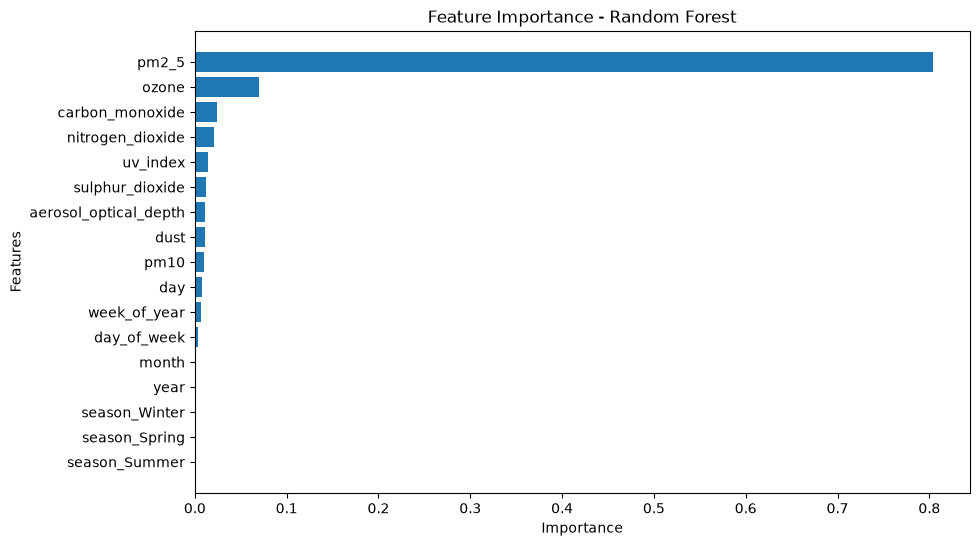

In [54]:
# اهمیت ویژگی ها
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": forest.feature_importances_
})

# مرتب سازی
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

# رسم نمودار
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()
plt.show()

مشخص است که:

pm2_5

تقریباً تمام تصمیم‌های مدل را تعیین می‌کند.

این از نظر علمی هم درست است، چون شاخص AQI در بسیاری از استانداردها بیشترین وابستگی را به PM2.5 دارد.

بعد از آن:

ozone

carbon_monoxide

nitrogen_dioxide

قرار گرفته‌اند که آن هم منطقی است.

## برسی نتایج

| Model             |      MAE |     RMSE |        R² |
| ----------------- | -------: | -------: | --------: |
| **Random Forest** | **6.90** | **8.82** | **0.745** |
| Linear Regression |     6.98 |     8.84 |     0.743 |
| Ridge Regression  |     6.99 |     8.86 |     0.742 |
| Lasso Regression  |     7.08 |     8.97 |     0.736 |
| SVR               |     7.63 |     9.67 |     0.693 |
| Decision Tree     |     7.75 |     9.88 |     0.680 |
| KNN Regressor     |     9.47 |    11.95 |     0.531 |



پس بهترین مدل کدام است؟




| **Random Forest** | **0.745** ✅ |




با برسی

 overfiting

 که انجام دادیم فهمیدیم که 
 
 random forest
 
 با اختلاف بسیار کمی  بهترین مدل ما شده است 

و در اخر میاییم از مدل ها یه برسی کلی میکنیم و مقایسه شون میکنیم

In [55]:
# ساخت جدول مقایسه مدل ها

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN Regressor",
        "Decision Tree",
        "Random Forest",
        "Ridge Regression",
        "Lasso Regression",
        "SVR"
    ],

    "MAE": [
        lr_mae,
        knn_mae,
        tree_mae,
        forest_mae,
        ridge_mae,
        lasso_mae,
        svr_mae
    ],

    "RMSE": [
        lr_rmse,
        knn_rmse,
        tree_rmse,
        forest_rmse,
        ridge_rmse,
        lasso_rmse,
        svr_rmse
    ],

    "R²": [
        lr_r2,
        knn_r2,
        tree_r2,
        forest_r2,
        ridge_r2,
        lasso_r2,
        svr_r2
    ]
})

# مرتب سازی بر اساس R²
results = results.sort_values("R²", ascending=False)

results.style.highlight_max(color="green")

,Model,MAE,RMSE,R²
3,Random Forest,6.899571,8.815930,0.744762
0,Linear Regression,6.975332,8.838879,0.743432
4,Ridge Regression,6.994189,8.856639,0.742400
5,Lasso Regression,7.082231,8.974131,0.735520
6,SVR,7.634486,9.667097,0.693097
2,Decision Tree,7.749932,9.878713,0.679514
1,KNN Regressor,9.468501,11.950343,0.531004


نمودار مقایسه مدل‌ها

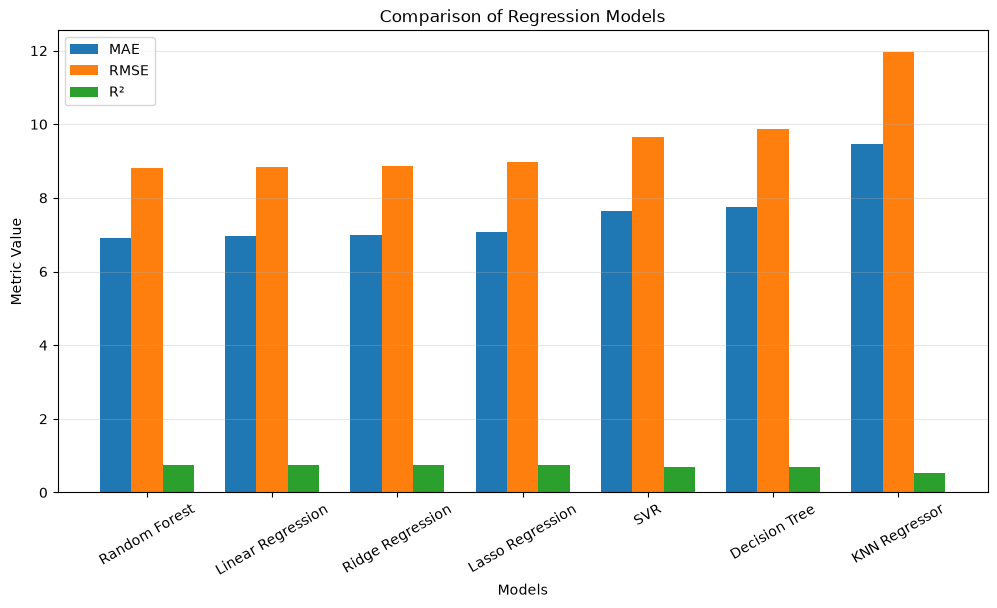

In [56]:
# تنظیم اندازه شکل
plt.figure(figsize=(12,6))

# موقعیت هر مدل روی محور x
x = np.arange(len(results))
width = 0.25

# رسم سه نمودار میله ای کنار هم
plt.bar(x - width, results["MAE"], width, label="MAE")
plt.bar(x, results["RMSE"], width, label="RMSE")
plt.bar(x + width, results["R²"], width, label="R²")

# تنظیمات نمودار
plt.xticks(x, results["Model"], rotation=30)
plt.title("Comparison of Regression Models")
plt.xlabel("Models")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [57]:
# مقایسه نهایی مدل ها

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN Regressor",
        "Decision Tree",
        "Random Forest",
        "Ridge Regression",
        "Lasso Regression",
        "SVR"
    ],
    "MAE": [lr_mae, knn_mae, tree_mae, forest_mae, ridge_mae, lasso_mae, svr_mae],
    "RMSE": [lr_rmse, knn_rmse, tree_rmse, forest_rmse, ridge_rmse, lasso_rmse, svr_rmse],
    "R²": [lr_r2, knn_r2, tree_r2, forest_r2, ridge_r2, lasso_r2, svr_r2]
})

# مرتب سازی بر اساس R²
results = results.sort_values(by="R²", ascending=False)

print(results)

               Model       MAE       RMSE        R²
3      Random Forest  6.899571   8.815930  0.744762
0  Linear Regression  6.975332   8.838879  0.743432
4   Ridge Regression  6.994189   8.856639  0.742400
5   Lasso Regression  7.082231   8.974131  0.735520
6                SVR  7.634486   9.667097  0.693097
2      Decision Tree  7.749932   9.878713  0.679514
1      KNN Regressor  9.468501  11.950343  0.531004


# نتیجه گیری 

Random Forest Regressor 

بهترین عملکرد را در پیش‌بینی کیفیت هوا داشت و به‌عنوان مدل نهایی انتخاب شد.


 Linear Regression وRidgeوLasso
 
 نیز نتایج بسیار نزدیکی به آن ارائه داد، در حالی که 
 
 KNN و Decision Treeو SVR 
 
  عملکرد ضعیف‌تری روی داده‌های تست داشتند.